# 03 — Demand Forecasting
Forecast monthly demand per product using LightGBM with log-transformed target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, pickle
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
PROCESSED = Path('../data/processed')
MODELS = Path('../models')
MODELS.mkdir(exist_ok=True)
print('Imports OK')

Imports OK


## 1. Load data

In [2]:
monthly = pd.read_parquet(PROCESSED / 'monthly_features.parquet')
products = pd.read_parquet(PROCESSED / 'product_features.parquet')
print(f'Monthly rows: {len(monthly):,}')
print(f'Months: {sorted(monthly["InvoiceMonth"].unique())}')

Monthly rows: 30,336
Months: ['2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08', '2011-09', '2011-10', '2011-11', '2011-12']


## 2. Feature engineering (raw scale — log only on target)

In [3]:
df = monthly.copy()
df = df.sort_values(['StockCode', 'InvoiceMonth']).reset_index(drop=True)

# Lag features on RAW quantity (not log)
for lag in [1, 2, 3]:
    df[f'qty_lag{lag}'] = df.groupby('StockCode')['monthly_quantity'].shift(lag)

df['qty_roll3'] = (
    df.groupby('StockCode')['monthly_quantity']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)
df['price_lag1'] = df.groupby('StockCode')['avg_price'].shift(1)
df['month_num'] = pd.to_datetime(df['InvoiceMonth']).dt.month

le = LabelEncoder()
df['stock_code_enc'] = le.fit_transform(df['StockCode'])

df = df.merge(
    products[['StockCode','total_revenue','num_customers','avg_unit_price','revenue_rank']],
    on='StockCode', how='left'
)
df = df.dropna(subset=['qty_lag1','qty_lag2','qty_lag3'])

# Log-transform TARGET only
df['log_quantity'] = np.log1p(df['monthly_quantity'])

print(f'Dataset shape: {df.shape}')
print(f'\nTarget stats (raw):')
print(df['monthly_quantity'].describe().round(1))
print(f'\nTarget stats (log):')
print(df['log_quantity'].describe().round(3))

Dataset shape: (20043, 20)

Target stats (raw):
count    20043.0
mean       180.1
std        398.7
min          1.0
25%         12.0
50%         50.0
75%        180.0
max      12215.0
Name: monthly_quantity, dtype: float64

Target stats (log):
count    20043.000
mean         3.911
std          1.703
min          0.693
25%          2.565
50%          3.932
75%          5.198
max          9.411
Name: log_quantity, dtype: float64


## 3. Train / validation split (time-based)

In [4]:
FEATURES = ['stock_code_enc','qty_lag1','qty_lag2','qty_lag3','qty_roll3',
            'price_lag1','month_num','avg_price','num_orders','num_customers_x',
            'total_revenue','avg_unit_price','revenue_rank']
TARGET = 'log_quantity'

sorted_months = sorted(df['InvoiceMonth'].unique())
val_months = sorted_months[-2:]
train_months = sorted_months[:-2]

train = df[df['InvoiceMonth'].isin(train_months)]
val   = df[df['InvoiceMonth'].isin(val_months)]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]

print(f'Train: {len(train):,} rows | {len(train_months)} months')
print(f'Val  : {len(val):,} rows  | {val_months}')

Train: 15,638 rows | 8 months
Val  : 4,405 rows  | ['2011-11', '2011-12']


## 4. Train LightGBM

In [5]:
model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    num_leaves=31, min_child_samples=10,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)
print(f'Best iteration: {model.best_iteration_}')

[100]	valid_0's l2: 0.448655
[200]	valid_0's l2: 0.419614
[300]	valid_0's l2: 0.404839
[400]	valid_0's l2: 0.400699
[500]	valid_0's l2: 0.397505
Best iteration: 494


## 5. Evaluate (on original scale)

MAE  : 68.6 units
RMSE : 233.9 units
MAPE : 62.9%


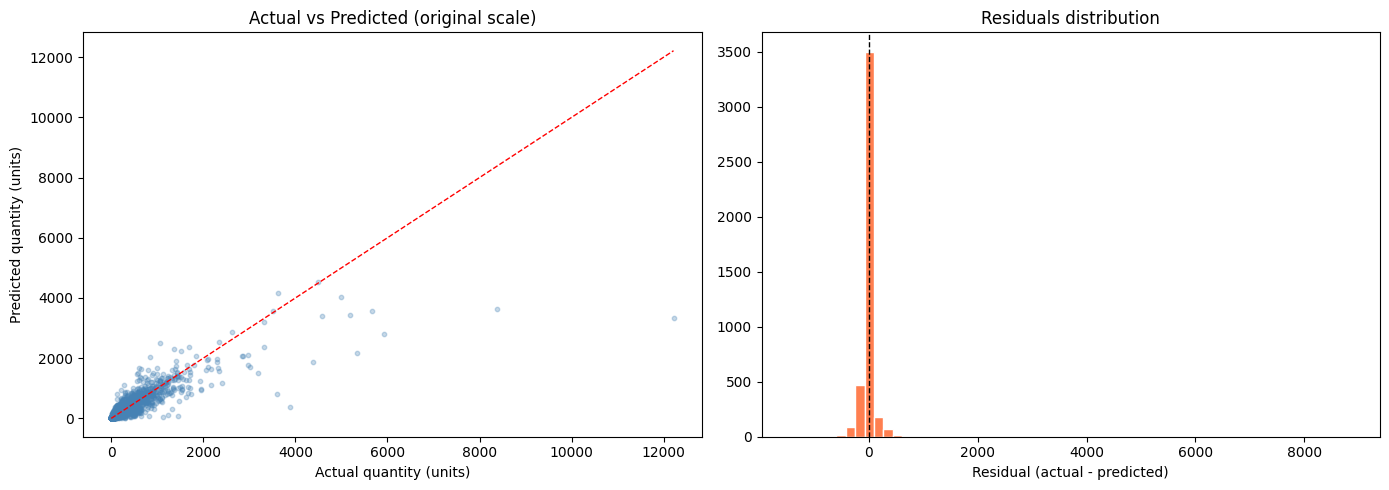

In [6]:
# Predict in log space, inverse transform back to units
preds_log = model.predict(X_val)
preds     = np.expm1(np.maximum(preds_log, 0))
actuals   = np.expm1(y_val.values)   # actual units

mae  = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
mape = np.mean(np.abs((actuals - preds) / (actuals + 1))) * 100

print(f'MAE  : {mae:.1f} units')
print(f'RMSE : {rmse:.1f} units')
print(f'MAPE : {mape:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs predicted in ORIGINAL units
axes[0].scatter(actuals, preds, alpha=0.3, s=10, color='steelblue')
max_val = max(actuals.max(), preds.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1)
axes[0].set_xlabel('Actual quantity (units)')
axes[0].set_ylabel('Predicted quantity (units)')
axes[0].set_title('Actual vs Predicted (original scale)')

residuals = actuals - preds
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual (actual - predicted)')
axes[1].set_title('Residuals distribution')
plt.tight_layout()
plt.show()

## 6. Feature importance

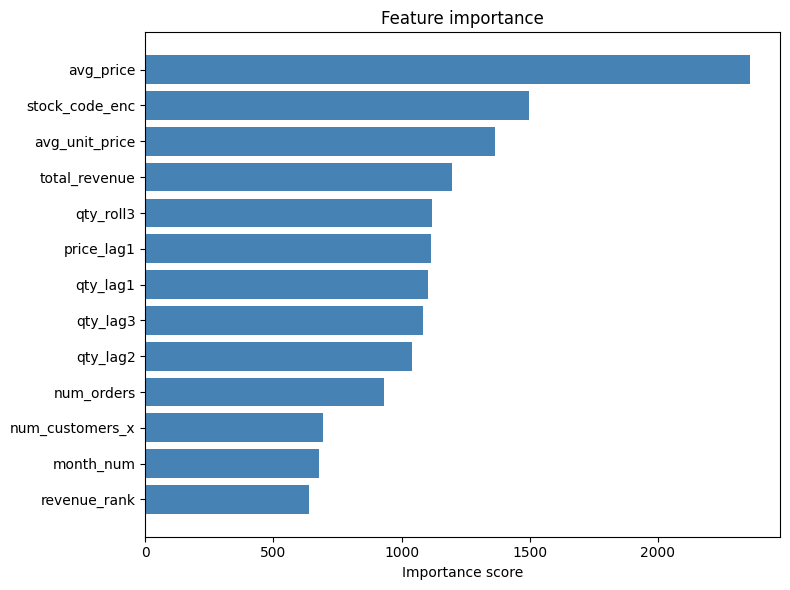

In [7]:
importance = pd.DataFrame({'feature': FEATURES, 'importance': model.feature_importances_})
importance = importance.sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_title('Feature importance')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

## 7. Save model and predictions

In [8]:
with open(MODELS / 'demand_model.pkl', 'wb') as f:
    pickle.dump({'model': model, 'features': FEATURES, 'label_encoder': le}, f)
print('Saved demand_model.pkl')

df['predicted_quantity'] = np.expm1(np.maximum(model.predict(df[FEATURES]), 0))
out = df[['StockCode','InvoiceMonth','monthly_quantity','predicted_quantity','avg_price']].copy()
out.to_parquet(PROCESSED / 'demand_predictions.parquet', index=False)
print('Saved demand_predictions.parquet')
out.head(10)

Saved demand_model.pkl
Saved demand_predictions.parquet


,StockCode,InvoiceMonth,monthly_quantity,predicted_quantity,avg_price
3,10002,2011-03,23,56.017733,0.85
4,10002,2011-04,189,65.389168,0.85
8,10080,2011-09,60,39.192605,0.39
9,10080,2011-10,6,16.011033,0.39
10,10080,2011-11,91,53.171134,0.39
14,10120,2011-05,3,9.784485,0.21
15,10120,2011-07,5,9.987543,0.21
16,10120,2011-08,35,17.002760,0.21
17,10120,2011-09,10,17.199990,0.21
18,10120,2011-10,10,9.335865,0.21


## 8. Sample forecasts — top 5 products by revenue

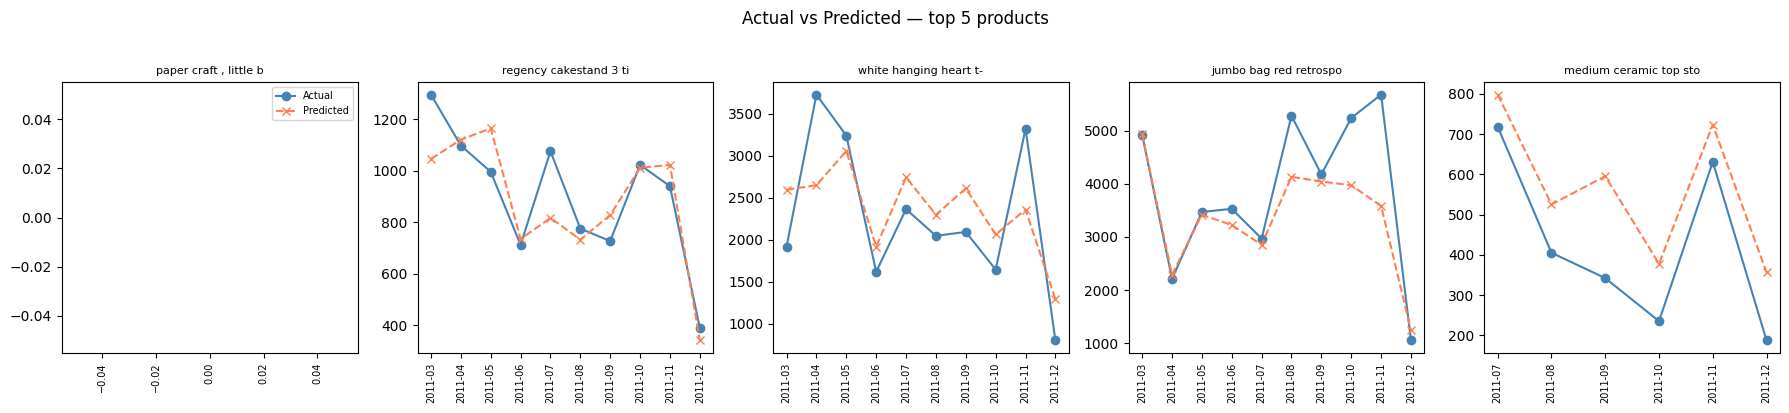

In [9]:
top5 = products.nsmallest(5, 'revenue_rank')['StockCode'].tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, sku in enumerate(top5):
    sub  = out[out['StockCode'] == sku].sort_values('InvoiceMonth')
    desc = products[products['StockCode'] == sku]['description'].values[0][:22]
    axes[i].plot(sub['InvoiceMonth'], sub['monthly_quantity'],
                 marker='o', label='Actual', color='steelblue')
    axes[i].plot(sub['InvoiceMonth'], sub['predicted_quantity'],
                 marker='x', linestyle='--', label='Predicted', color='coral')
    axes[i].set_title(desc, fontsize=8)
    axes[i].tick_params(axis='x', rotation=90, labelsize=7)
    if i == 0:
        axes[i].legend(fontsize=7)
plt.suptitle('Actual vs Predicted — top 5 products', y=1.02)
plt.tight_layout()
plt.show()